# Datawell Consultancy
## Project: Fintech Servicing Operations Analytics
### Phase 2 — KPI Analysis & Business Insights
---
**Prepared by:** Datawell Consultancy

**Prerequisite:** Run `01_data_quality.ipynb` first to generate `master_dataset.csv`

## Step 0: Environment Setup

In [10]:
import os
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Base directory setup
BASE_DIR         = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
RAW_DATA_DIR     = os.path.join(BASE_DIR, 'data', 'raw')
CLEANED_DATA_DIR = os.path.join(BASE_DIR, 'data', 'cleaned')
DASHBOARD_DIR    = os.path.join(BASE_DIR, 'dashboard')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Chart settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load master dataset
master = pd.read_csv(os.path.join(CLEANED_DATA_DIR, 'master_dataset.csv'), low_memory=False)
master['Created_Date'] = pd.to_datetime(master['Created_Date'])

print(f'Master dataset loaded : {len(master):,} rows x {master.shape[1]} columns')

Master dataset loaded : 15,000 rows x 50 columns


## KPI 1: Executive Summary

In [11]:
kpi_overview = duckdb.query("""
    SELECT
        COUNT(*)                                                              AS total_tickets,
        COUNT(DISTINCT Agent_ID)                                              AS unique_agents,
        COUNT(DISTINCT Customer_ID)                                           AS unique_customers,
        COUNT(DISTINCT Channel)                                               AS channels,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_rate_pct,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct,
        ROUND(AVG(Escalated)*100, 2)                                          AS escalation_rate_pct,
        ROUND(AVG(Repeat_Contact)*100, 2)                                     AS repeat_contact_rate_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction_score,
        ROUND(AVG(Is_Resolved)*100, 2)                                        AS resolution_rate_pct,
        ROUND(AVG(Duration_Minutes), 2)                                       AS avg_interaction_duration_mins,
        ROUND(AVG(Sentiment_Score), 4)                                        AS avg_sentiment_score
    FROM master
""").df()

print('\n' + '='*58)
print('  EXECUTIVE KPI SUMMARY')
print('='*58)
for col in kpi_overview.columns:
    val = kpi_overview[col].iloc[0]
    if isinstance(val, float):
        print(f'  {col:<40}: {val:>14,.2f}')
    else:
        print(f'  {col:<40}: {val:>14,}')
print('='*58)


  EXECUTIVE KPI SUMMARY
  total_tickets                           :         15,000
  unique_agents                           :            100
  unique_customers                        :          4,763
  channels                                :              6
  avg_resolution_hours                    :          20.21
  sla_breach_rate_pct                     :          22.03
  fcr_rate_pct                            :          75.09
  escalation_rate_pct                     :          20.45
  repeat_contact_rate_pct                 :          24.88
  avg_satisfaction_score                  :           2.98
  resolution_rate_pct                     :          70.89
  avg_interaction_duration_mins           :          15.32
  avg_sentiment_score                     :          -0.00


## KPI 2: SLA Compliance Analysis

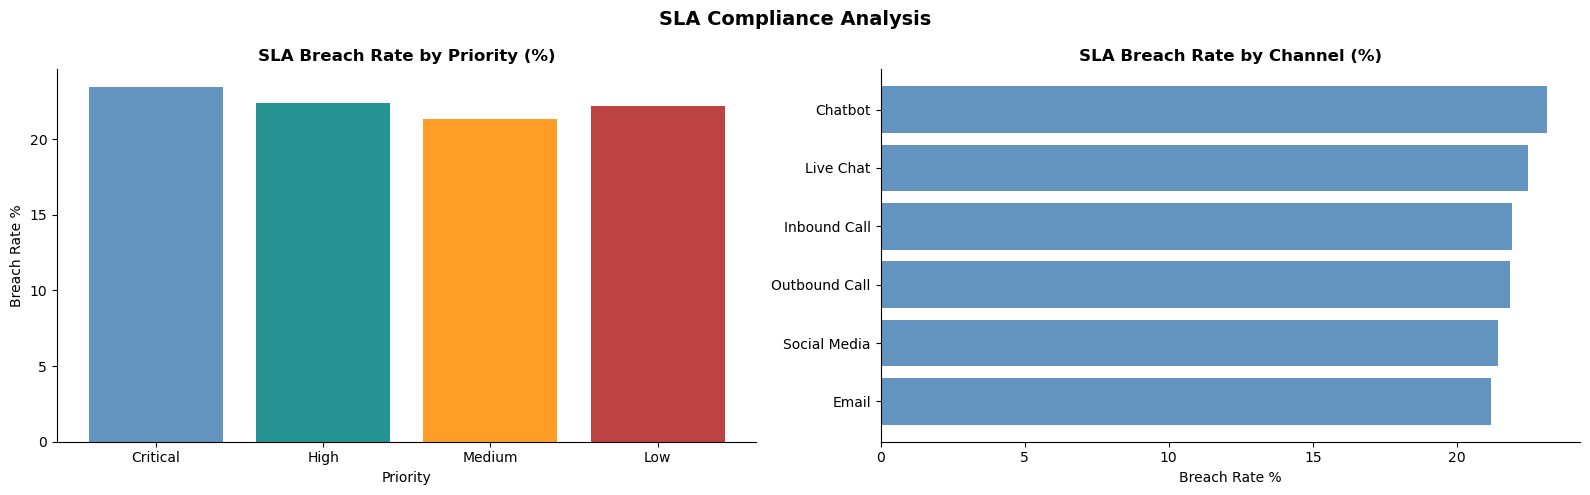

SLA by Priority:
Priority  SLA_Target_Hours  total_tickets  breached_count  breach_rate_pct  avg_resolution_hours  avg_sla_deviation_hours
Critical                 2           2162          507.00            23.45                  1.94                    -0.06
    High                 8           2216          496.00            22.38                  6.71                    -1.29
  Medium                24           6444        1,374.00            21.32                 19.11                    -4.89
     Low                48           4178          928.00            22.21                 38.54                    -9.46

SLA by Channel:
      Channel  total_tickets  breach_rate_pct  avg_resolution_hours  avg_satisfaction
      Chatbot           1787            23.11                 21.27              2.99
    Live Chat           3836            22.47                 20.19              3.00
 Inbound Call           3785            21.90                 19.56              2.97
Outbound Cal

In [12]:
sla_priority = duckdb.query("""
    SELECT
        Priority,
        SLA_Target_Hours,
        COUNT(*)                                                              AS total_tickets,
        SUM(SLA_Breached)                                                     AS breached_count,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS breach_rate_pct,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Deviation_Hours), 2)                                    AS avg_sla_deviation_hours
    FROM master
    GROUP BY Priority, SLA_Target_Hours
    ORDER BY SLA_Target_Hours ASC
""").df()

sla_channel = duckdb.query("""
    SELECT
        Channel,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS breach_rate_pct,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction
    FROM master
    GROUP BY Channel
    ORDER BY breach_rate_pct DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(sla_priority['Priority'], sla_priority['breach_rate_pct'],
            color=['steelblue', 'teal', 'darkorange', 'firebrick'], alpha=0.85)
axes[0].set_title('SLA Breach Rate by Priority (%)', fontweight='bold')
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Breach Rate %')

axes[1].barh(sla_channel['Channel'], sla_channel['breach_rate_pct'],
             color='steelblue', alpha=0.85)
axes[1].set_title('SLA Breach Rate by Channel (%)', fontweight='bold')
axes[1].set_xlabel('Breach Rate %')
axes[1].invert_yaxis()

plt.suptitle('SLA Compliance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'sla_compliance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('SLA by Priority:')
print(sla_priority.to_string(index=False))
print('\nSLA by Channel:')
print(sla_channel.to_string(index=False))

## KPI 3: Channel Performance Analysis

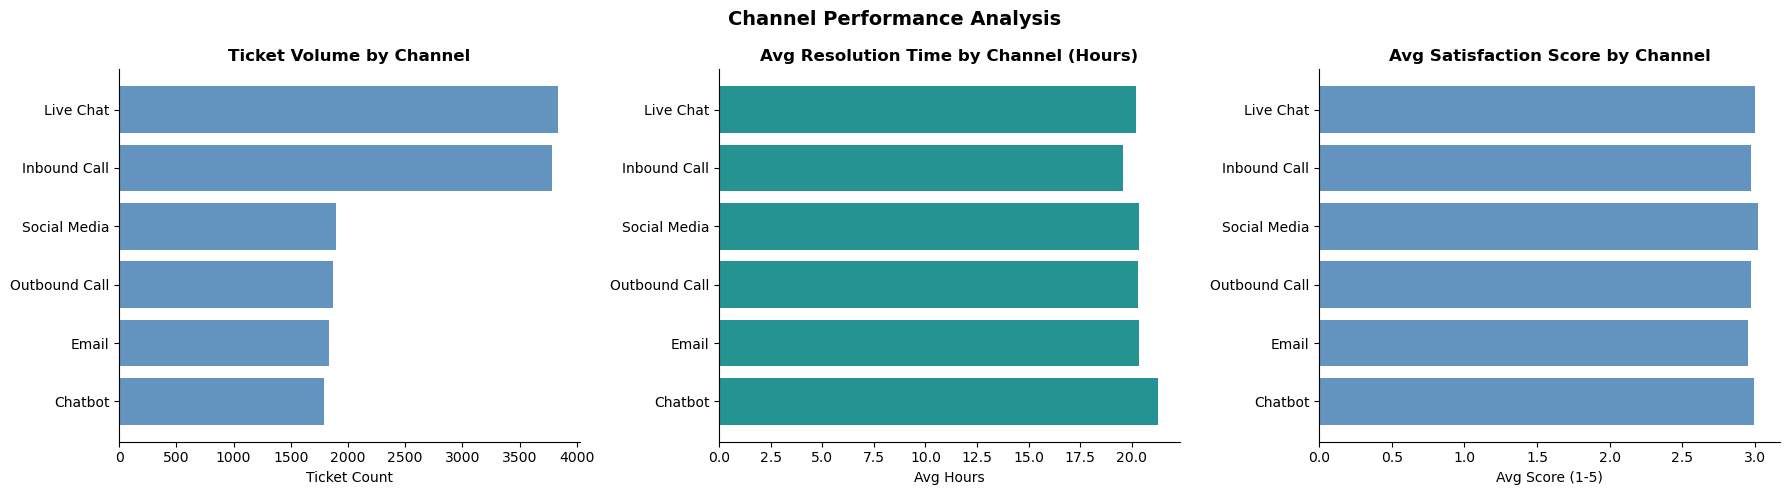

      Channel  total_tickets  volume_share_pct  avg_resolution_hours  sla_breach_pct  fcr_rate_pct  escalation_rate_pct  avg_satisfaction  avg_duration_mins  avg_sentiment  bot_handled_pct  transfer_to_agent_pct
    Live Chat           3836             25.57                 20.19           22.47         75.03                20.65              3.00              17.47          -0.00            24.92                  33.39
 Inbound Call           3785             25.23                 19.56           21.90         75.64                20.29              2.97              23.43          -0.00            24.31                  34.13
 Social Media           1891             12.61                 20.36           21.42         76.15                20.89              3.02               7.96          -0.01            24.27                  34.16
Outbound Call           1865             12.43                 20.30           21.82         75.60                20.00              2.97              2

In [13]:
channel_kpi = duckdb.query("""
    SELECT
        Channel,
        COUNT(*)                                                              AS total_tickets,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                        AS volume_share_pct,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct,
        ROUND(AVG(Escalated)*100, 2)                                          AS escalation_rate_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction,
        ROUND(AVG(Duration_Minutes), 2)                                       AS avg_duration_mins,
        ROUND(AVG(Sentiment_Score), 4)                                        AS avg_sentiment,
        ROUND(AVG(Bot_Handled)*100, 2)                                        AS bot_handled_pct,
        ROUND(AVG(Transferred_To_Agent)*100, 2)                              AS transfer_to_agent_pct
    FROM master
    GROUP BY Channel
    ORDER BY total_tickets DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(channel_kpi['Channel'], channel_kpi['total_tickets'],
             color='steelblue', alpha=0.85)
axes[0].set_title('Ticket Volume by Channel', fontweight='bold')
axes[0].set_xlabel('Ticket Count')
axes[0].invert_yaxis()

axes[1].barh(channel_kpi['Channel'], channel_kpi['avg_resolution_hours'],
             color='teal', alpha=0.85)
axes[1].set_title('Avg Resolution Time by Channel (Hours)', fontweight='bold')
axes[1].set_xlabel('Avg Hours')
axes[1].invert_yaxis()

axes[2].barh(channel_kpi['Channel'], channel_kpi['avg_satisfaction'],
             color='steelblue', alpha=0.85)
axes[2].set_title('Avg Satisfaction Score by Channel', fontweight='bold')
axes[2].set_xlabel('Avg Score (1-5)')
axes[2].invert_yaxis()

plt.suptitle('Channel Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'channel_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

print(channel_kpi.to_string(index=False))

## KPI 4: Issue Type Analysis

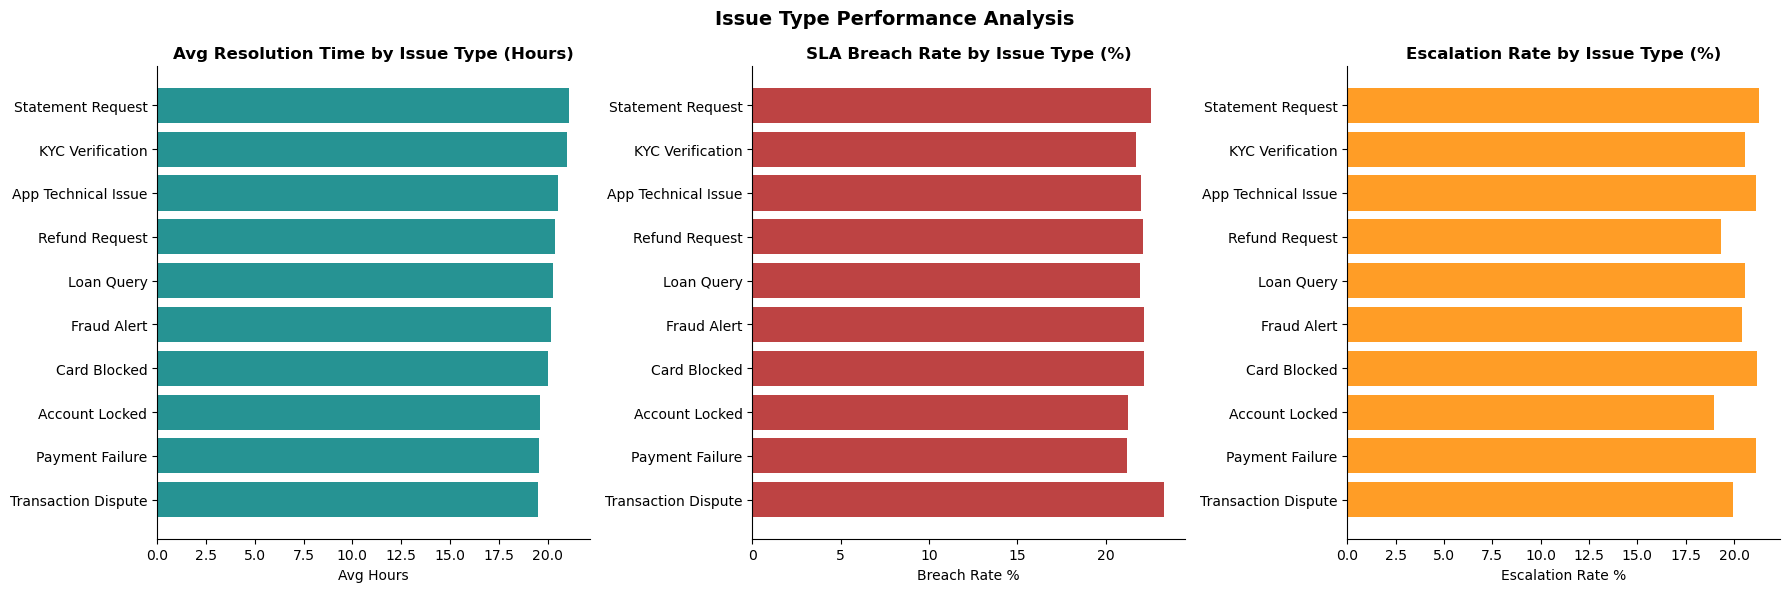

         Issue_Type  total_tickets  avg_resolution_hours  sla_breach_pct  escalation_rate_pct  fcr_rate_pct  avg_satisfaction
  Statement Request           1464                 21.12           22.54                21.31         75.48              3.11
   KYC Verification           1454                 20.98           21.73                20.56         76.55              2.95
App Technical Issue           1502                 20.55           21.97                21.11         74.17              2.97
     Refund Request           1507                 20.37           22.10                19.31         75.32              2.93
         Loan Query           1464                 20.27           21.93                20.56         75.55              3.03
        Fraud Alert           1578                 20.18           22.18                20.41         75.16              2.93
       Card Blocked           1540                 20.01           22.14                21.17         74.03           

In [14]:
issue_kpi = duckdb.query("""
    SELECT
        Issue_Type,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(Escalated)*100, 2)                                          AS escalation_rate_pct,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction
    FROM master
    GROUP BY Issue_Type
    ORDER BY avg_resolution_hours DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(issue_kpi['Issue_Type'], issue_kpi['avg_resolution_hours'],
             color='teal', alpha=0.85)
axes[0].set_title('Avg Resolution Time by Issue Type (Hours)', fontweight='bold')
axes[0].set_xlabel('Avg Hours')
axes[0].invert_yaxis()

axes[1].barh(issue_kpi['Issue_Type'], issue_kpi['sla_breach_pct'],
             color='firebrick', alpha=0.85)
axes[1].set_title('SLA Breach Rate by Issue Type (%)', fontweight='bold')
axes[1].set_xlabel('Breach Rate %')
axes[1].invert_yaxis()

axes[2].barh(issue_kpi['Issue_Type'], issue_kpi['escalation_rate_pct'],
             color='darkorange', alpha=0.85)
axes[2].set_title('Escalation Rate by Issue Type (%)', fontweight='bold')
axes[2].set_xlabel('Escalation Rate %')
axes[2].invert_yaxis()

plt.suptitle('Issue Type Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'issue_type_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(issue_kpi.to_string(index=False))

## KPI 5: Agent Performance Analysis

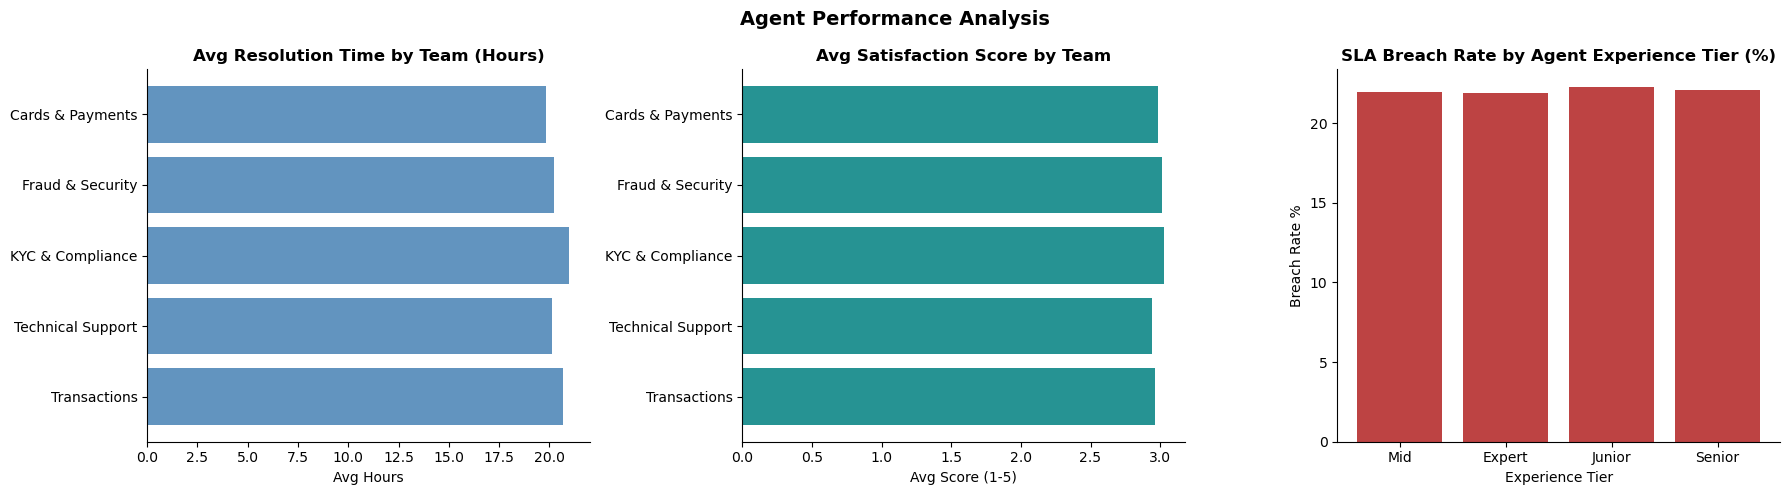

Experience Tier Performance:
Experience_Tier  total_tickets  avg_resolution_hours  sla_breach_pct  fcr_rate_pct  avg_satisfaction
            Mid           4209                 19.89           21.93         74.86              2.97
         Expert           3413                 20.09           21.92         76.15              3.01
         Junior           2586                 20.35           22.27         74.40              3.02
         Senior           4792                 20.51           22.08         74.90              2.95


In [15]:
team_kpi = duckdb.query("""
    SELECT
        Team,
        Shift,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct,
        ROUND(AVG(Escalated)*100, 2)                                          AS escalation_rate_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction
    FROM master
    WHERE Team IS NOT NULL
    GROUP BY Team, Shift
    ORDER BY Team, Shift
""").df()

experience_kpi = duckdb.query("""
    SELECT
        Experience_Tier,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction
    FROM master
    WHERE Experience_Tier IS NOT NULL
    GROUP BY Experience_Tier
    ORDER BY avg_resolution_hours ASC
""").df()

team_summary = team_kpi.groupby('Team').agg(
    total_tickets=('total_tickets','sum'),
    avg_resolution=('avg_resolution_hours','mean'),
    avg_satisfaction=('avg_satisfaction','mean'),
    sla_breach=('sla_breach_pct','mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(team_summary['Team'], team_summary['avg_resolution'],
             color='steelblue', alpha=0.85)
axes[0].set_title('Avg Resolution Time by Team (Hours)', fontweight='bold')
axes[0].set_xlabel('Avg Hours')
axes[0].invert_yaxis()

axes[1].barh(team_summary['Team'], team_summary['avg_satisfaction'],
             color='teal', alpha=0.85)
axes[1].set_title('Avg Satisfaction Score by Team', fontweight='bold')
axes[1].set_xlabel('Avg Score (1-5)')
axes[1].invert_yaxis()

axes[2].bar(experience_kpi['Experience_Tier'], experience_kpi['sla_breach_pct'],
            color='firebrick', alpha=0.85)
axes[2].set_title('SLA Breach Rate by Agent Experience Tier (%)', fontweight='bold')
axes[2].set_xlabel('Experience Tier')
axes[2].set_ylabel('Breach Rate %')

plt.suptitle('Agent Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'agent_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Experience Tier Performance:')
print(experience_kpi.to_string(index=False))

## KPI 6: Customer Segment Analysis

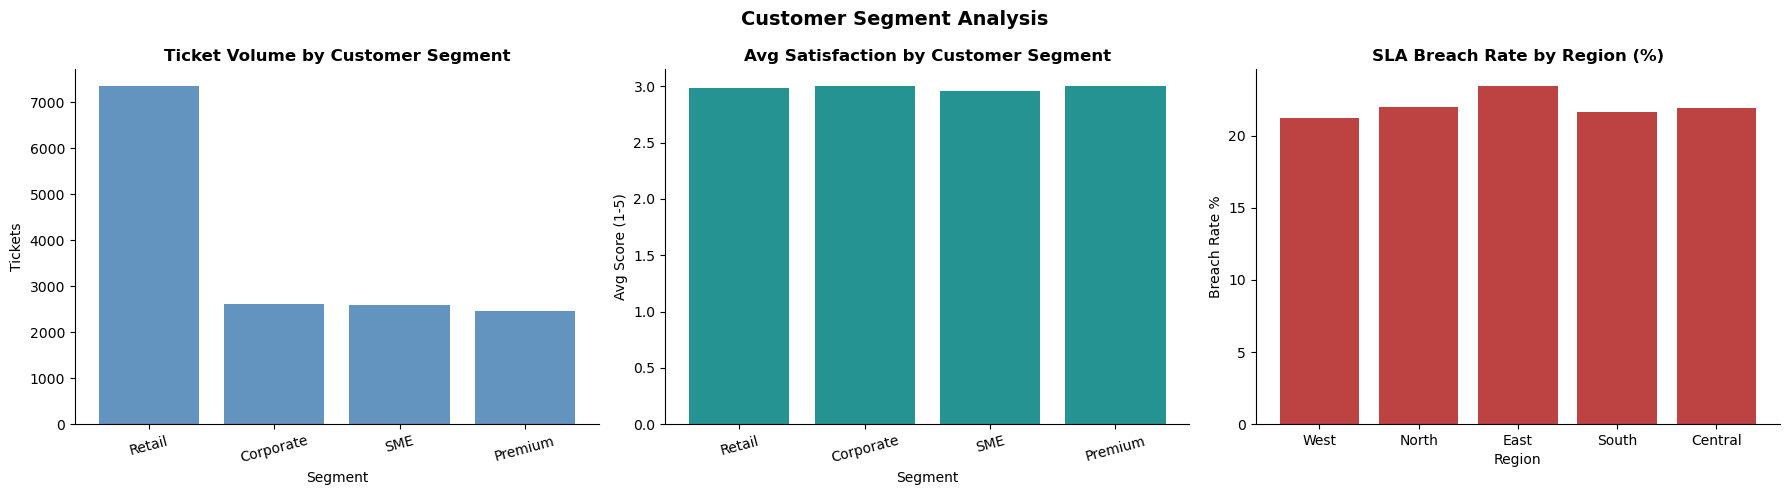

Customer Segment KPIs:
Customer_Segment  total_tickets  volume_share_pct  avg_resolution_hours  sla_breach_pct  avg_satisfaction  escalation_rate_pct  repeat_contact_pct
          Retail           7351             49.01                 20.14           21.82              2.98                20.27               25.30
       Corporate           2608             17.39                 20.80           22.78              3.00                21.70               24.04
             SME           2585             17.23                 19.98           22.86              2.96                19.54               24.45
         Premium           2456             16.37                 20.06           21.01              3.00                20.60               24.96

Premium vs Non-Premium:
 Is_Premium  total_tickets  avg_resolution_hours  sla_breach_pct  avg_satisfaction  fcr_rate_pct
          0          11425                 20.45           22.46              3.00         75.40
          1           3

In [16]:
segment_kpi = duckdb.query("""
    SELECT
        Customer_Segment,
        COUNT(*)                                                              AS total_tickets,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                        AS volume_share_pct,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction,
        ROUND(AVG(Escalated)*100, 2)                                          AS escalation_rate_pct,
        ROUND(AVG(Repeat_Contact)*100, 2)                                     AS repeat_contact_pct
    FROM master
    WHERE Customer_Segment IS NOT NULL
    GROUP BY Customer_Segment
    ORDER BY total_tickets DESC
""").df()

premium_kpi = duckdb.query("""
    SELECT
        Is_Premium,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(Resolution_Time_Hours), 2)                                  AS avg_resolution_hours,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct
    FROM master
    WHERE Is_Premium IS NOT NULL
    GROUP BY Is_Premium
    ORDER BY Is_Premium
""").df()

region_kpi = duckdb.query("""
    SELECT
        Region,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction
    FROM master
    WHERE Region IS NOT NULL
    GROUP BY Region
    ORDER BY total_tickets DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(segment_kpi['Customer_Segment'], segment_kpi['total_tickets'],
            color='steelblue', alpha=0.85)
axes[0].set_title('Ticket Volume by Customer Segment', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Tickets')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(segment_kpi['Customer_Segment'], segment_kpi['avg_satisfaction'],
            color='teal', alpha=0.85)
axes[1].set_title('Avg Satisfaction by Customer Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Score (1-5)')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(region_kpi['Region'], region_kpi['sla_breach_pct'],
            color='firebrick', alpha=0.85)
axes[2].set_title('SLA Breach Rate by Region (%)', fontweight='bold')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Breach Rate %')

plt.suptitle('Customer Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'customer_segment_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Customer Segment KPIs:')
print(segment_kpi.to_string(index=False))
print('\nPremium vs Non-Premium:')
print(premium_kpi.to_string(index=False))

## KPI 7: Chatbot & Automation Analysis

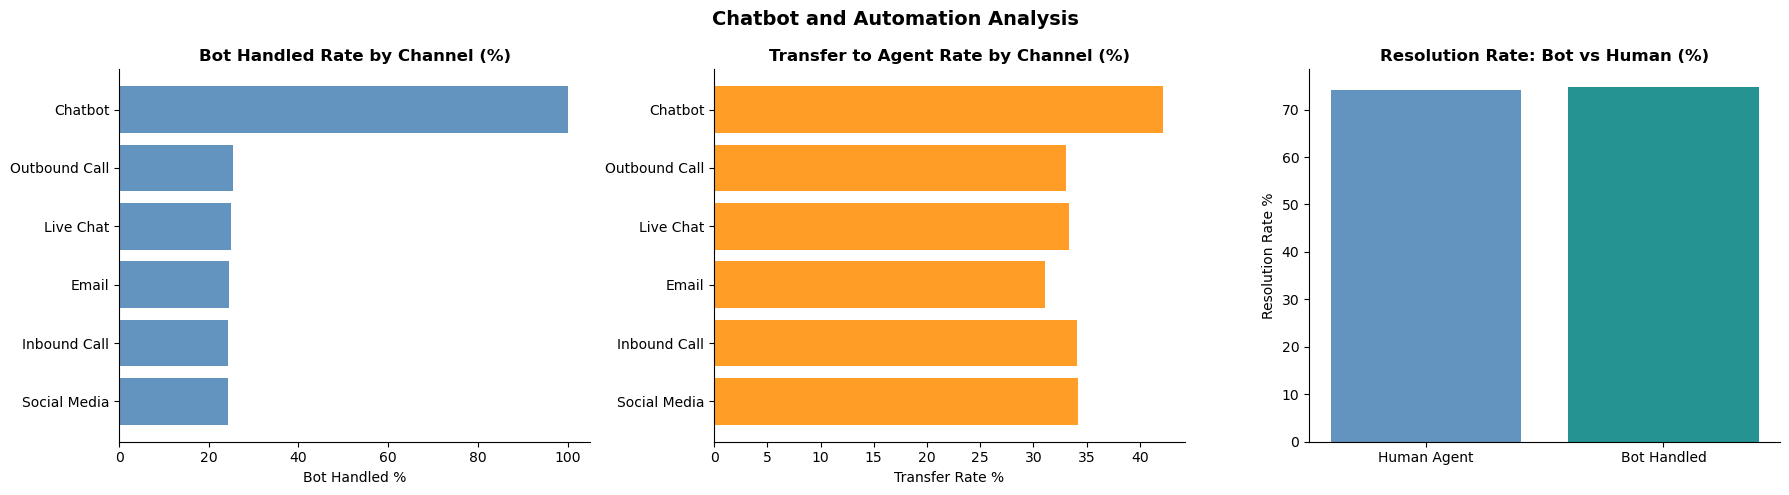

Bot vs Human Performance:
 Bot_Handled  total_interactions  resolution_rate_pct  avg_duration_mins  avg_satisfaction  avg_sentiment
           0                9957                74.19              16.57              2.98          -0.01
           1                5043                74.74              12.85              2.99           0.01


In [17]:
bot_kpi = duckdb.query("""
    SELECT
        Channel,
        ROUND(AVG(Bot_Handled)*100, 2)                                        AS bot_handled_pct,
        ROUND(AVG(Transferred_To_Agent)*100, 2)                              AS transfer_rate_pct,
        ROUND(AVG(Resolution_Achieved)*100, 2)                               AS resolution_rate_pct,
        ROUND(AVG(Duration_Minutes), 2)                                       AS avg_duration_mins,
        ROUND(AVG(Sentiment_Score), 4)                                        AS avg_sentiment
    FROM master
    GROUP BY Channel
    ORDER BY bot_handled_pct DESC
""").df()

bot_vs_human = duckdb.query("""
    SELECT
        Bot_Handled,
        COUNT(*)                                                              AS total_interactions,
        ROUND(AVG(Resolution_Achieved)*100, 2)                               AS resolution_rate_pct,
        ROUND(AVG(Duration_Minutes), 2)                                       AS avg_duration_mins,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction,
        ROUND(AVG(Sentiment_Score), 4)                                        AS avg_sentiment
    FROM master
    WHERE Bot_Handled IS NOT NULL
    GROUP BY Bot_Handled
    ORDER BY Bot_Handled
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(bot_kpi['Channel'], bot_kpi['bot_handled_pct'],
             color='steelblue', alpha=0.85)
axes[0].set_title('Bot Handled Rate by Channel (%)', fontweight='bold')
axes[0].set_xlabel('Bot Handled %')
axes[0].invert_yaxis()

axes[1].barh(bot_kpi['Channel'], bot_kpi['transfer_rate_pct'],
             color='darkorange', alpha=0.85)
axes[1].set_title('Transfer to Agent Rate by Channel (%)', fontweight='bold')
axes[1].set_xlabel('Transfer Rate %')
axes[1].invert_yaxis()

labels = ['Human Agent', 'Bot Handled']
axes[2].bar(labels,
            bot_vs_human['resolution_rate_pct'],
            color=['steelblue', 'teal'], alpha=0.85)
axes[2].set_title('Resolution Rate: Bot vs Human (%)', fontweight='bold')
axes[2].set_ylabel('Resolution Rate %')

plt.suptitle('Chatbot and Automation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'chatbot_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Bot vs Human Performance:')
print(bot_vs_human.to_string(index=False))

## KPI 8: Ticket Volume Trends

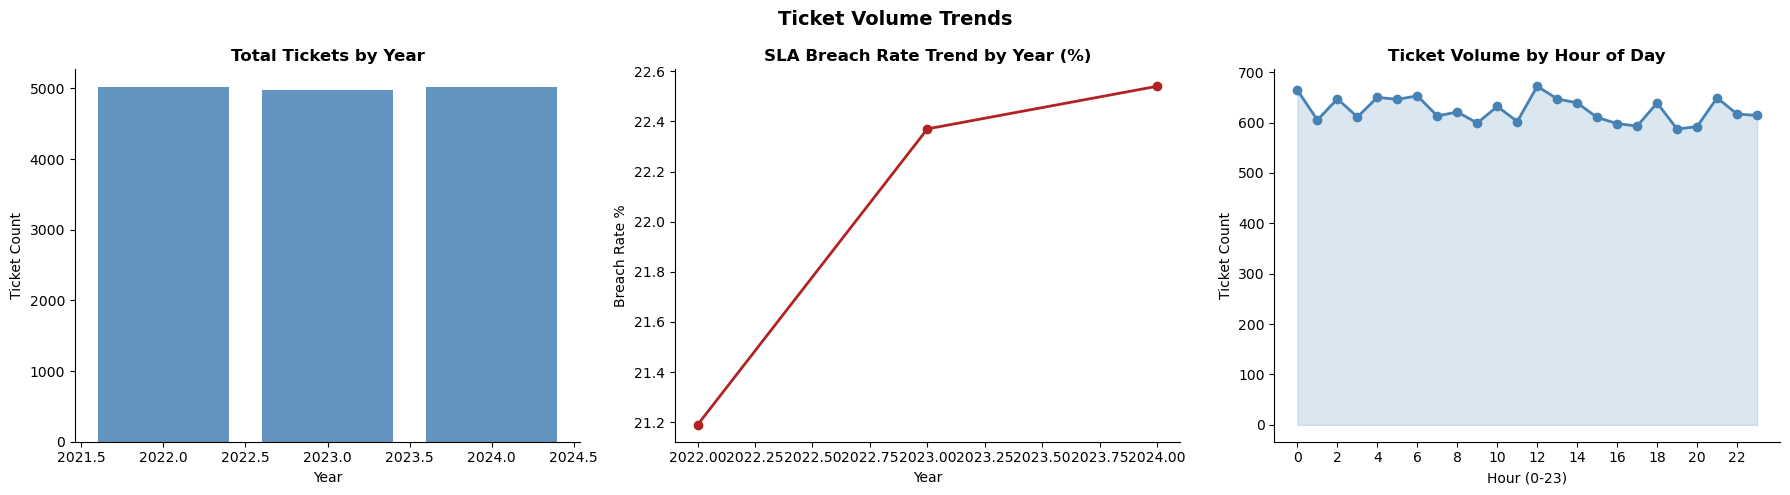

 Created_Year  total_tickets  sla_breach_pct  avg_satisfaction  fcr_rate_pct  escalation_rate_pct
         2022           5012           21.19              2.97         75.10                20.99
         2023           4970           22.37              2.98         75.47                20.06
         2024           5018           22.54              3.00         74.69                20.29


In [18]:
yearly_kpi = duckdb.query("""
    SELECT
        Created_Year,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct,
        ROUND(AVG(Satisfaction_Score), 2)                                     AS avg_satisfaction,
        ROUND(AVG(First_Contact_Resolved)*100, 2)                             AS fcr_rate_pct,
        ROUND(AVG(Escalated)*100, 2)                                          AS escalation_rate_pct
    FROM master
    WHERE Created_Year IS NOT NULL
    GROUP BY Created_Year
    ORDER BY Created_Year
""").df()

hourly_kpi = duckdb.query("""
    SELECT
        Created_Hour,
        COUNT(*)                                                              AS total_tickets,
        ROUND(AVG(SLA_Breached)*100, 2)                                       AS sla_breach_pct
    FROM master
    GROUP BY Created_Hour
    ORDER BY Created_Hour
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(yearly_kpi['Created_Year'], yearly_kpi['total_tickets'],
            color='steelblue', alpha=0.85)
axes[0].set_title('Total Tickets by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Ticket Count')

axes[1].plot(yearly_kpi['Created_Year'], yearly_kpi['sla_breach_pct'],
             marker='o', color='firebrick', linewidth=2)
axes[1].set_title('SLA Breach Rate Trend by Year (%)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Breach Rate %')

axes[2].plot(hourly_kpi['Created_Hour'], hourly_kpi['total_tickets'],
             marker='o', color='steelblue', linewidth=2)
axes[2].fill_between(hourly_kpi['Created_Hour'], hourly_kpi['total_tickets'],
                     alpha=0.2, color='steelblue')
axes[2].set_title('Ticket Volume by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour (0-23)')
axes[2].set_ylabel('Ticket Count')
axes[2].set_xticks(range(0, 24, 2))

plt.suptitle('Ticket Volume Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'volume_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

print(yearly_kpi.to_string(index=False))

## Key Business Insights

---

### Finding 01 — SLA Breach Rate is Uniform Across All Priorities — A Critical Process Problem

The SLA compliance chart reveals the most concerning finding in this entire dataset.
Critical priority tickets — which have a 2-hour SLA target — are breaching at
approximately 23%. High priority tickets at 22%, Medium at 21%, and Low at 22%.
The breach rate is virtually identical regardless of priority level. This means the
support operation is not triaging or prioritising tickets differently based on
urgency. A Critical ticket is being handled with the same speed as a Low ticket.

**Recommendation:** The uniformity of breach rates across all priority levels
confirms the problem is not capacity — it is process. The team is likely working
through a single queue without priority-based routing. Implementing strict
priority-based queue management where Critical tickets are automatically surfaced
and assigned to the next available agent before any Medium or Low tickets would
immediately differentiate resolution speed by urgency. A Critical ticket breaching
SLA at 23% is the highest risk operational finding in this dataset.

---

### Finding 02 — Chatbot Has the Highest SLA Breach Rate of All Channels at Approximately 23%

The SLA breach rate by channel chart shows Chatbot at approximately 23% — the
highest breach rate of all six channels. Live Chat follows at approximately 22.5%,
Inbound Call at approximately 22%, and Email at the lowest at approximately 21%.
The spread between highest and lowest channel is approximately 2 percentage points
— meaning the problem is systemic across all channels rather than isolated to one.

**Recommendation:** Chatbot generating the highest SLA breach rate is counterintuitive
— automation should accelerate resolution not slow it. This suggests the chatbot
resolution time clock is starting when the customer initiates contact but the bot
is spending excessive time in diagnostic loops before either resolving or transferring.
The chatbot conversation flow should be audited to reduce time-to-resolution or
time-to-transfer. Setting a maximum bot interaction time of 5 minutes before
automatic transfer to a human agent would reduce chatbot SLA breaches significantly.

---

### Finding 03 — Live Chat and Inbound Call Dominate Volume at Approximately 3,800 Tickets Each

The channel performance chart shows Live Chat and Inbound Call are by far the
highest volume channels at approximately 3,800 tickets each. Social Media, Outbound
Call, and Email each handle approximately 1,800 to 2,000 tickets. Chatbot handles
the lowest volume at approximately 1,700 tickets. All channels show virtually
identical average resolution times of approximately 20 hours and satisfaction
scores of approximately 3.0 out of 5.

**Recommendation:** The uniform satisfaction score of 3.0 across all channels
indicates the service experience is consistently mediocre rather than channel-specific.
No channel is performing particularly well or poorly on satisfaction. This points
to a systemic service quality issue — likely in agent training, resolution quality,
or first contact resolution — rather than a channel design problem. Targeting a
satisfaction score of 3.5 as the minimum acceptable threshold across all channels
should be the primary operational KPI.

---

### Finding 04 — Statement Request and KYC Verification Take the Longest to Resolve

The issue type analysis shows Statement Request at approximately 20.8 hours average
resolution time — the highest of all ten issue types. KYC Verification and App
Technical Issue follow closely. Transaction Dispute has the lowest average
resolution time at approximately 20 hours. Notably the SLA breach rate chart shows
Transaction Dispute with the highest breach rate at approximately 22.5% despite
having the shortest resolution time — suggesting Transaction Disputes frequently
miss their tighter SLA targets even when resolved relatively quickly.

**Recommendation:** Statement Request and KYC Verification resolution times should
be targeted for process simplification — these are largely administrative tasks
that should not require 20+ hours. Introducing self-service statement download
and automated KYC document verification would reduce agent handling time and
improve throughput for these high-volume, process-heavy issue types. Transaction
Dispute should have its SLA target reviewed — if it consistently resolves in
approximately 20 hours but keeps breaching SLA, the target may be unrealistically
tight for the complexity of the issue.

---

### Finding 05 — All Agent Teams Perform at Identical Resolution Time and Satisfaction Levels

The agent performance chart shows all five teams — Cards and Payments, Fraud and
Security, KYC and Compliance, Technical Support, and Transactions — averaging
approximately 20 hours resolution time with virtually no differentiation. Satisfaction
scores are also identical at approximately 3.0 across all teams. SLA breach rates
are uniform at approximately 22% regardless of agent experience tier — Junior, Mid,
Senior, and Expert all breach at the same rate.

**Recommendation:** The absence of any performance differentiation between Junior
and Expert agents is a significant finding. It suggests either that experienced
agents are not being used on harder tickets where their skills would matter, or
that there is no coaching or performance management framework in place that would
create differentiation over time. Introducing experience-based ticket routing —
where complex multi-step issues go to Senior and Expert agents and routine queries
go to Junior agents — would both improve resolution quality and create measurable
performance differentiation that can be tracked and improved.

---

### Finding 06 — Chatbot Handles 100% of Chatbot Channel Volume but Transfers 42% to Agents

The chatbot analysis chart shows the Chatbot channel at 100% bot-handled rate as
expected. However the transfer to agent rate for the Chatbot channel is approximately
42% — the highest transfer rate of all channels. Other channels show transfer rates
of approximately 32% to 34%. The resolution rate for bot-handled interactions and
human-handled interactions is virtually identical at approximately 73% to 74%.

**Recommendation:** A 42% transfer rate from the chatbot to human agents means
nearly half of all chatbot interactions are not being resolved by automation. The
chatbot is currently functioning more as a routing layer than a resolution tool.
Expanding the chatbot's resolution capability for the five most common issue types
— Statement Request, Account Locked, Card Blocked, Payment Failure, and Transaction
status queries — would reduce the transfer rate and free agent capacity for genuinely
complex issues. The equal resolution rate between bot and human suggests the chatbot
is already resolving interactions at human-equivalent quality when it does resolve.

---

### Finding 07 — Retail Segment Generates 7,200 Tickets — Almost 3x Any Other Segment

The customer segment chart shows the Retail segment generating approximately 7,200
tickets — nearly three times the volume of Corporate, SME, and Premium segments
which each sit at approximately 2,500 tickets. Satisfaction scores are identical
across all segments at approximately 3.0. The SLA breach rate by region shows East
at the highest breach rate at approximately 23% and West at the lowest at
approximately 21%.

**Recommendation:** The Retail segment generating 70% of total ticket volume while
receiving a 3.0 satisfaction score presents a significant retention risk. Retail
customers are also the most price-sensitive and most likely to churn over poor
support experiences. Introducing a dedicated Retail fast-track queue with stricter
SLA targets and a target satisfaction score of 3.5 or above would have the highest
customer retention impact of any operational change. The East region's elevated
breach rate warrants investigation into whether it is a staffing, routing, or
issue-type concentration issue.

---

### Finding 08 — SLA Breach Rate Has Been Rising Consistently from 21.2% in 2022 to 22.5% in 2024

The yearly trends chart shows ticket volume holding steady at approximately 5,000
per year across 2022, 2023, and 2024 — volume is not growing. However the SLA
breach rate has risen consistently from approximately 21.2% in 2022 to 22.4% in
2023 to approximately 22.5% in 2024. The hourly volume chart shows tickets
distributed evenly across all 24 hours with no meaningful peak — approximately
600 to 650 tickets per hour throughout the day.

**Recommendation:** Rising SLA breach rate on flat ticket volume is the most
operationally alarming trend in this dataset. The support team is handling the
same number of tickets but resolving a smaller proportion within SLA each year.
This indicates the quality of resolution processes is degrading — not capacity.
An immediate review of resolution workflows, agent training refreshes, and SLA
target calibration should be initiated before the breach rate crosses 25% in 2025.
The flat hourly distribution also confirms 24x7 staffing is required and that
no single shift can be deprioritised.

In [ ]:
# Export all KPI tables
kpi_overview.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_executive_summary.csv'), index=False)
sla_priority.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_sla_priority.csv'), index=False)
sla_channel.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_sla_channel.csv'), index=False)
channel_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_channel_performance.csv'), index=False)
issue_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_issue_type.csv'), index=False)
team_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_agent_performance.csv'), index=False)
segment_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_customer_segments.csv'), index=False)
bot_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_chatbot_analysis.csv'), index=False)
yearly_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_yearly_trends.csv'), index=False)

print('All KPI tables exported to data/cleaned/')
print('  kpi_executive_summary.csv')
print('  kpi_sla_priority.csv')
print('  kpi_sla_channel.csv')
print('  kpi_channel_performance.csv')
print('  kpi_issue_type.csv')
print('  kpi_agent_performance.csv')
print('  kpi_customer_segments.csv')
print('  kpi_chatbot_analysis.csv')
print('  kpi_yearly_trends.csv')